# [LAB 05] 로지스틱 회귀 Channel 분류
## 구매 패턴 기반 고객 군집 노트북과 동일 전처리 → Channel(1/2) 예측

- **전처리**: 구매액 6개 np.log1p → StandardScaler, 학습 피처는 **스케일된 log 6개 + Region** 7개
- **타겟**: Channel (1 또는 2) → 라벨 0/1로 변환하여 이진 분류
- **모델**: 로지스틱 회귀 분류기
- **저장**: scaler, LogisticRegression 모델 각각 pkl 저장


## 1. 라이브러리 및 데이터 로드

In [1]:
from hossam import load_data
import pandas as pd
import numpy as np
from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)
import pickle
from pathlib import Path

my_dpi = 200
RAW_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
LAB05_DIR = Path('.').resolve()

from sklearn.linear_model import LogisticRegression


In [2]:
origin = load_data('wholesale_customers')
# Region 포함 (XGBoosting 예제 참고: https://xgboosting.com/xgboost-for-the-wholesale-customers-dataset/)
df = origin[RAW_COLS + ['Region', 'Channel']].copy()
df.head(10)

이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region,Channel
0,12669,9656,7561,214,2674,1338,3,2
1,7057,9810,9568,1762,3293,1776,3,2
2,6353,8808,7684,2405,3516,7844,3,2
3,13265,1196,4221,6404,507,1788,3,1
4,22615,5410,7198,3915,1777,5185,3,2
5,9413,8259,5126,666,1795,1451,3,2
6,12126,3199,6975,480,3140,545,3,2
7,7579,4956,9426,1669,3321,2566,3,2
8,5963,3648,6192,425,1716,750,3,1
9,6006,11093,18881,1159,7425,2098,3,2


## 2. 전처리

In [3]:
df_log = df[RAW_COLS].copy()
for c in RAW_COLS:
    df_log[f'log_{c}'] = np.log1p(df_log[c])
df_log['Region'] = df['Region'].values  # Region은 로그 변환 없이 추가

scaler = StandardScaler()
sdf = DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)
log_cols = [f'log_{c}' for c in RAW_COLS]
FEATURE_COLS = log_cols + ['Region']  # 학습 피처 7개: log 6 + Region
X = sdf[FEATURE_COLS].values
y = (df['Channel'] - 1).values  # 1,2 → 0,1

print('X shape:', X.shape)
print('y unique:', np.unique(y))
X[:3]

X shape: (440, 7)
y unique: [0 1]


array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595,  0.59066829],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606,  0.59066829],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339,  0.59066829]])

## 2.5 성능평가 함수 (LAB 09 공통)

LAB 09 `03-로지스틱 성능평가함수개선.ipynb`에서 사용하는 **이진 분류 성능평가**·**학습 곡선(과적합 판정)** 함수를 정의합니다.

In [4]:
def hs_cls_bin_scores(estimator, x_test, y_test):
    """이진 분류 성능평가 + ROC 곡선 (LAB 09 03-로지스틱 성능평가함수개선)"""
    y_pred_proba = estimator.predict_proba(x_test)
    y_pred_proba_1 = y_pred_proba[:, 1]
    y_pred = estimator.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    ((TN, FP), (FN, TP)) = cm
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__
    auc = roc_auc_score(y_test, y_pred_proba_1)
    score_df = DataFrame({
        "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
        "정밀도(Precision)": [precision_score(y_test, y_pred, zero_division=0)],
        "재현율(Recall,tpr)": [recall_score(y_test, y_pred, zero_division=0)],
        "위양성률(Fallout,fpr)": [FP / (TN + FP) if (TN + FP) > 0 else 0],
        "특이성(TNR)": [1 - (FP / (TN + FP)) if (TN + FP) > 0 else 0],
        "F1-Score": [f1_score(y_test, y_pred, zero_division=0)],
        "AUC": [auc]
    }, index=[classname])
    roc_fpr, roc_tpr, _ = roc_curve(y_test, y_pred_proba_1)
    fig, ax = plt.subplots(1, 1, figsize=(1000/my_dpi, 900/my_dpi), dpi=my_dpi)
    sb.lineplot(x=roc_fpr, y=roc_tpr)
    sb.lineplot(x=[0, 1], y=[0, 1], color='red', linestyle=":", alpha=0.5)
    plt.fill_between(x=roc_fpr, y1=roc_tpr, alpha=0.1)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC={auc:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
    plt.close()
    return score_df

In [5]:
def hs_learning_cv(
    estimator,
    x,
    y,
    scoring=None,  # <-- None 으로 기본값 수정
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    # =====================================================
    # [NEW] 문제 유형 자동 판별
    # =====================================================
    is_classification = (
        hasattr(estimator, "_estimator_type")
        and estimator._estimator_type == "classifier"
    )

    # =====================================================
    # [NEW] scoring 자동 설정
    # =====================================================
    if scoring is None:
        scoring = "roc_auc" if is_classification else "neg_root_mean_squared_error"

    # =====================================================
    # learning_curve 계산
    # =====================================================
    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=False,
        random_state=52,
    )

    # =====================================================
    # 모델명 추출 (Pipeline 대응)
    # =====================================================
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # =====================================================
    # 회귀 전용 처리
    # =====================================================
    if not is_classification:

        # neg RMSE → RMSE
        train_rmse = -train_scores
        cv_rmse = -cv_scores

        train_mean = train_rmse.mean(axis=1)
        cv_mean = cv_rmse.mean(axis=1)
        cv_std = cv_rmse.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train / final_cv
        var_ratio = final_std / final_cv

        # -------------------------------
        # 기준 RMSE 계산
        # -------------------------------
        y_mean = y.mean()
        rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

        std_y = y.std()

        min_r2 = 0.10
        rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

        some_threshold = min(rmse_naive, std_y, rmse_r2)

        train_slope = train_mean[-1] - train_mean[-2]
        cv_slope = cv_mean[-1] - cv_mean[-2]

        if gap_ratio >= 0.95 and final_cv > some_threshold:
            status = "⚠ 과소적합"
        elif gap_ratio <= 0.8 and train_slope > 0 and cv_slope < 0:
            status = "⚠ 데이터 추가시 일반화 기대"
        elif gap_ratio <= 0.8:
            status = "⚠ 과대적합"
        elif gap_ratio >= 0.95 and var_ratio <= 0.10:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.15:
            status = "⚠ 데이터 부족"
        else:
            status = "⚠ 판단유보"

        metric_name = "RMSE"

    # =====================================================
    # 분류 전용 처리
    # =====================================================
    else:

        train_metric = train_scores
        cv_metric = cv_scores

        train_mean = train_metric.mean(axis=1)
        cv_mean = cv_metric.mean(axis=1)
        cv_std = cv_metric.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train - final_cv
        var_ratio = final_std

        if final_train < 0.6 and final_cv < 0.6:
            status = "⚠ 과소적합"
        elif gap_ratio > 0.1:
            status = "⚠ 과대적합"
        elif gap_ratio <= 0.05 and var_ratio <= 0.05:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.1:
            status = "⚠ 데이터 부족"
        else:
            status = "⚠ 판단유보"

        metric_name = scoring.upper()

    # =====================================================
    # 결과 정리
    # =====================================================
    result_df = DataFrame(
        {
            f"Train {metric_name}": [final_train],
            f"CV {metric_name} 평균": [final_cv],
            f"CV {metric_name} 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # =====================================================
    # 학습곡선 시각화
    # =====================================================
    figsize = (1280 / my_dpi, 720 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"Train {metric_name}",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"CV {metric_name}",
    )

    ax.set_xlabel("학습 데이터 크기", fontsize=8, labelpad=5)
    ax.set_ylabel("성능", fontsize=8, labelpad=5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return result_df

## 3. train/test split 및 로지스틱 회귀 학습

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=52, stratify=y
)

clf = LogisticRegression(C=0.1, random_state=52, max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
y_pred_proba_1 = y_pred_proba[:, 1]  # 양성(Channel=2) 확률


## 4. 성능 지표: Accuracy, Confusion Matrix, ROC-AUC

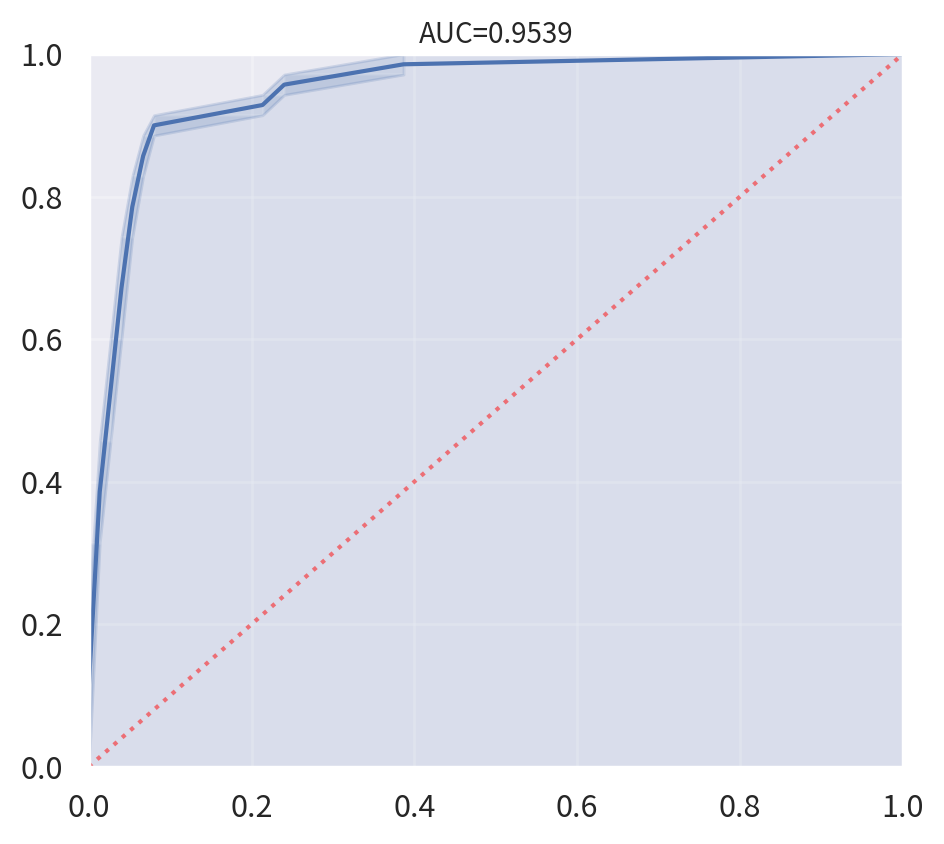

,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
LogisticRegression,0.891,0.897,0.743,0.040,0.960,0.812,0.954


In [7]:
# LAB 09 공통 함수: 이진 분류 성능평가 + ROC 곡선
score_df = hs_cls_bin_scores(clf, X_test, y_test)
score_df

## 4.6 학습 곡선 및 과적합 판정 (LAB 09 방식)

LAB 09 `02-로지스틱 성능평가.ipynb` #07 과적합 판정 방식을 그대로 사용합니다.  
learning_curve(roc_auc) → Train/CV 평균·표준편차 → 과소적합/과대적합/일반화 양호/데이터 부족/판단 보류 → 학습 곡선 그래프.

In [8]:
# LAB 09 #07: estimator, classname, scoring, cv, train_sizes
estimator = clf
if hasattr(estimator, "named_steps"):
    classname = estimator.named_steps["model"].__class__.__name__
else:
    classname = estimator.__class__.__name__

scoring = "roc_auc"
cv = 5
train_sizes = np.linspace(0.1, 1.0, 10)
n_jobs = -1

train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring=scoring,
    n_jobs=n_jobs,
    shuffle=False,
    random_state=52,
)

# 분류: ROC_AUC는 그대로 사용 (높을수록 좋음)
train_metric = train_scores
cv_metric = cv_scores
train_mean = train_metric.mean(axis=1)
cv_mean = cv_metric.mean(axis=1)
cv_std = cv_metric.std(axis=1)
final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]
gap_ratio = final_train - final_cv
var_ratio = final_std

if final_train < 0.6 and final_cv < 0.6:
    status = "⚠ 과소적합"
elif gap_ratio > 0.1:
    status = "⚠ 과대적합"
elif gap_ratio <= 0.05 and var_ratio <= 0.05:
    status = "✅ 일반화 양호"
elif var_ratio > 0.1:
    status = "⚠ 데이터 부족"
else:
    status = "⚠ 판단 보류"

metric_name = scoring.upper()
result_df_lc = DataFrame(
    {
        f"Train {metric_name} 평균": [round(final_train, 3)],
        f"CV {metric_name} 평균": [round(final_cv, 3)],
        f"CV {metric_name} 표준편차": [round(final_std, 3)],
        "Train/CV 비율": [round(gap_ratio, 3)],
        "CV 변동성 비율": [round(var_ratio, 3)],
        "판정 결과": [status],
    },
    index=[classname],
)
result_df_lc

,Train ROC_AUC 평균,CV ROC_AUC 평균,CV ROC_AUC 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
LogisticRegression,0.970,0.959,0.026,0.011,0.026,✅ 일반화 양호


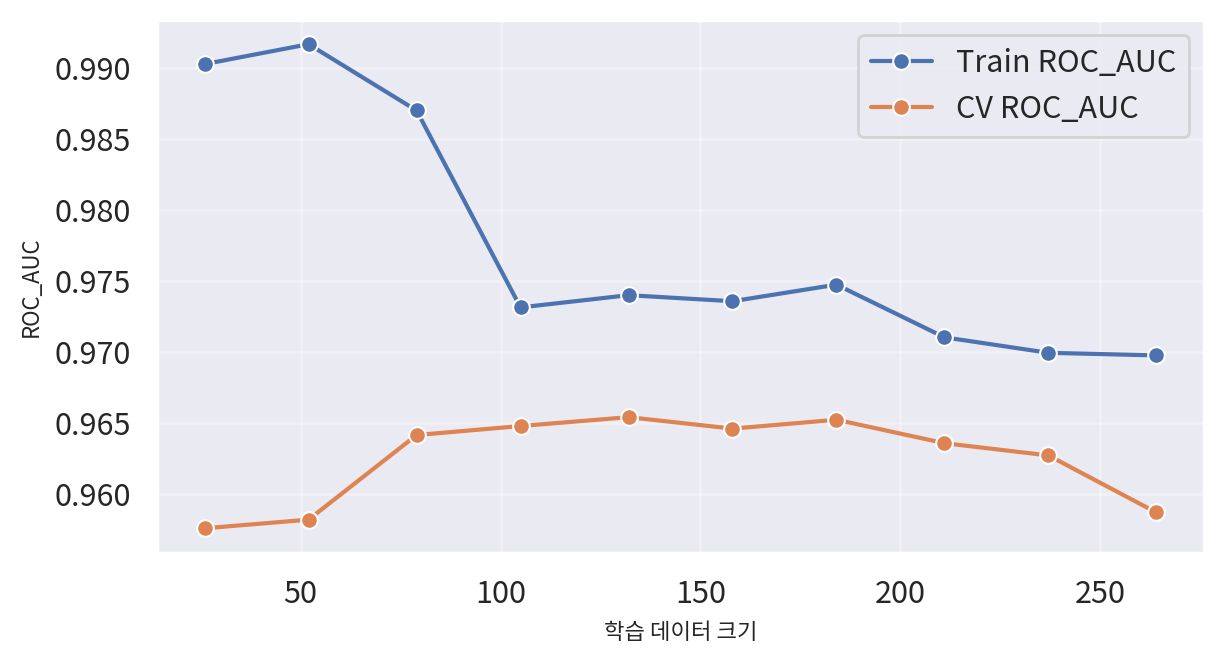

In [9]:
# LAB 09 #07 [2] 학습 곡선 그래프
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)
sb.lineplot(x=train_sizes, y=train_mean, marker="o", markeredgecolor="#ffffff", label=f"Train {metric_name}")
sb.lineplot(x=train_sizes, y=cv_mean, marker="o", markeredgecolor="#ffffff", label=f"CV {metric_name}")
ax.set_xlabel("학습 데이터 크기", fontsize=8)
ax.set_ylabel(metric_name, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## 5. Scaler / 모델 저장

In [11]:
scaler_path = LAB05_DIR / 'wholesale_scaler.pkl'
model_path = LAB05_DIR / 'wholesale_logistic.pkl'

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
with open(model_path, 'wb') as f:
    pickle.dump(clf, f)

print('저장 완료:', scaler_path)
print('저장 완료:', model_path)


저장 완료: C:\Machine_Learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_scaler.pkl
저장 완료: C:\Machine_Learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_logistic.pkl
